In [5]:
import cfg
from libs.data_request import DataRequest
from libs.analyzers import SignalStabilityAnalyzer
import matplotlib.pyplot as plt

log = cfg.set_logger()
dr = DataRequest(log=log, base_url=cfg.API_URL)

camp_ids = {'FM': 176}
target_nodes = [1, 2, 3, 4, 5, 6, 7, 9, 10]

[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api


In [6]:
df_full = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)

datos_nodos = df_full["FM"]
#Initialize the analyzer
analyzer = SignalStabilityAnalyzer(datos_nodos, global_range=(-27, 6))

[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['FM'] and nodes: [1, 2, 3, 4, 5, 6, 7, 9, 10]

🚀 Starting Campaign: FM
  ↳ Node 1 loaded instantly from local cache
  ↳ Node 2 loaded instantly from local cache
  ↳ Node 3 loaded instantly from local cache
  ↳ Node 4 loaded instantly from local cache
  ↳ Node 5 loaded instantly from local cache
  ↳ Node 6 loaded instantly from local cache
  ↳ Node 7 loaded instantly from local cache
  ↳ Node 9 loaded instantly from local cache
  ↳ Node 10 loaded instantly from local cache
[IPYKERNEL_LAUNCHER]INFO      Finished loading data for all campaigns and nodes.


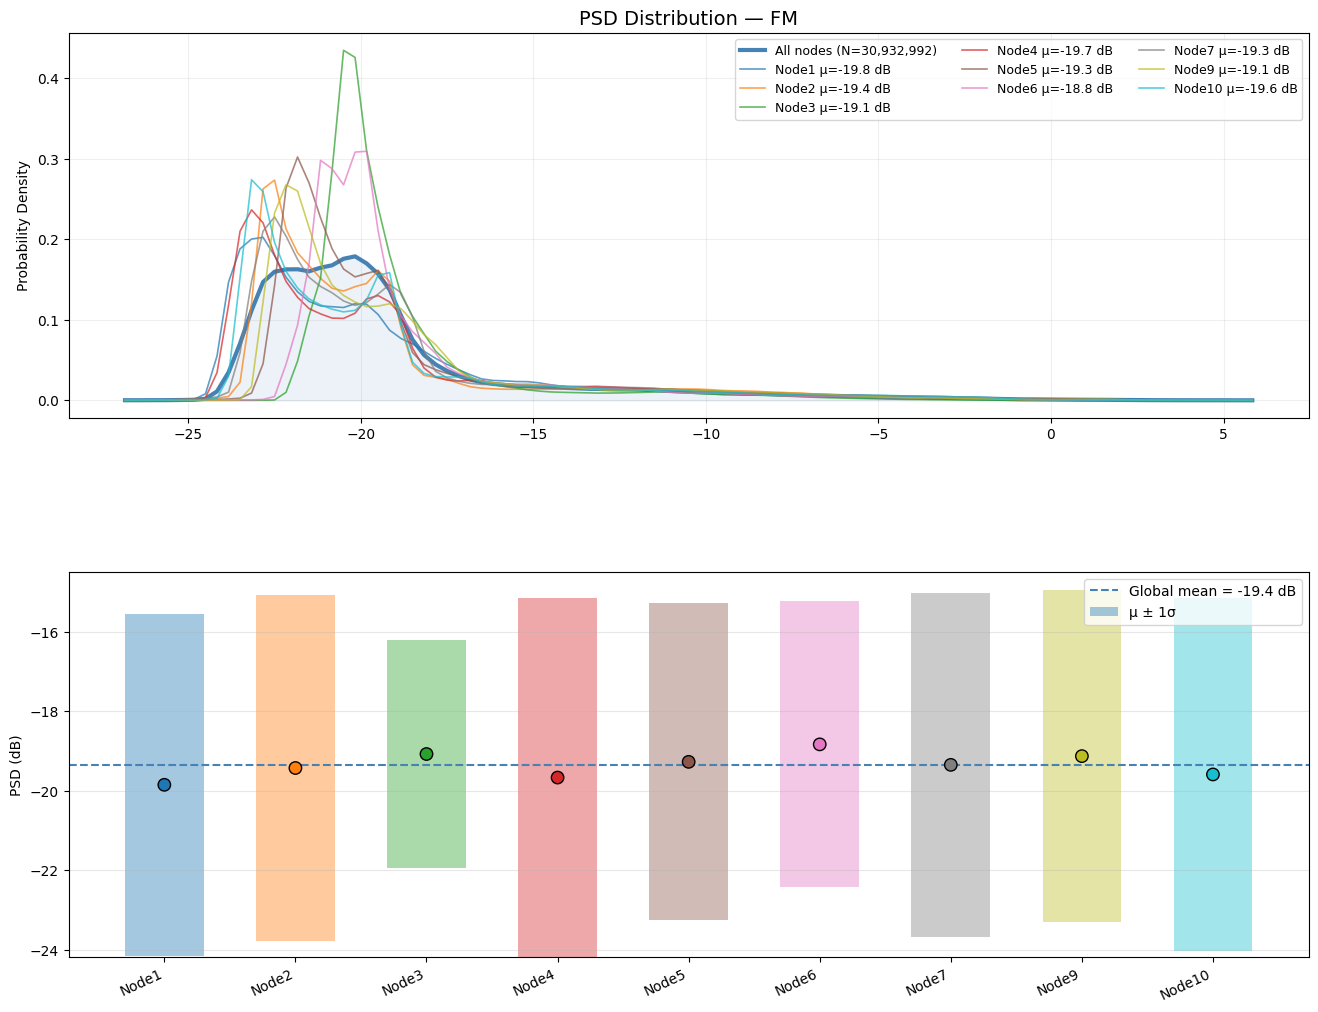

In [7]:
#Execute Histogram Analysis
# This parses all rows, calculates densities, and plots Panel A (Overlay) and Panel B (Mean/Std)
analyzer.execute_one_histogram(campaign_name="FM")

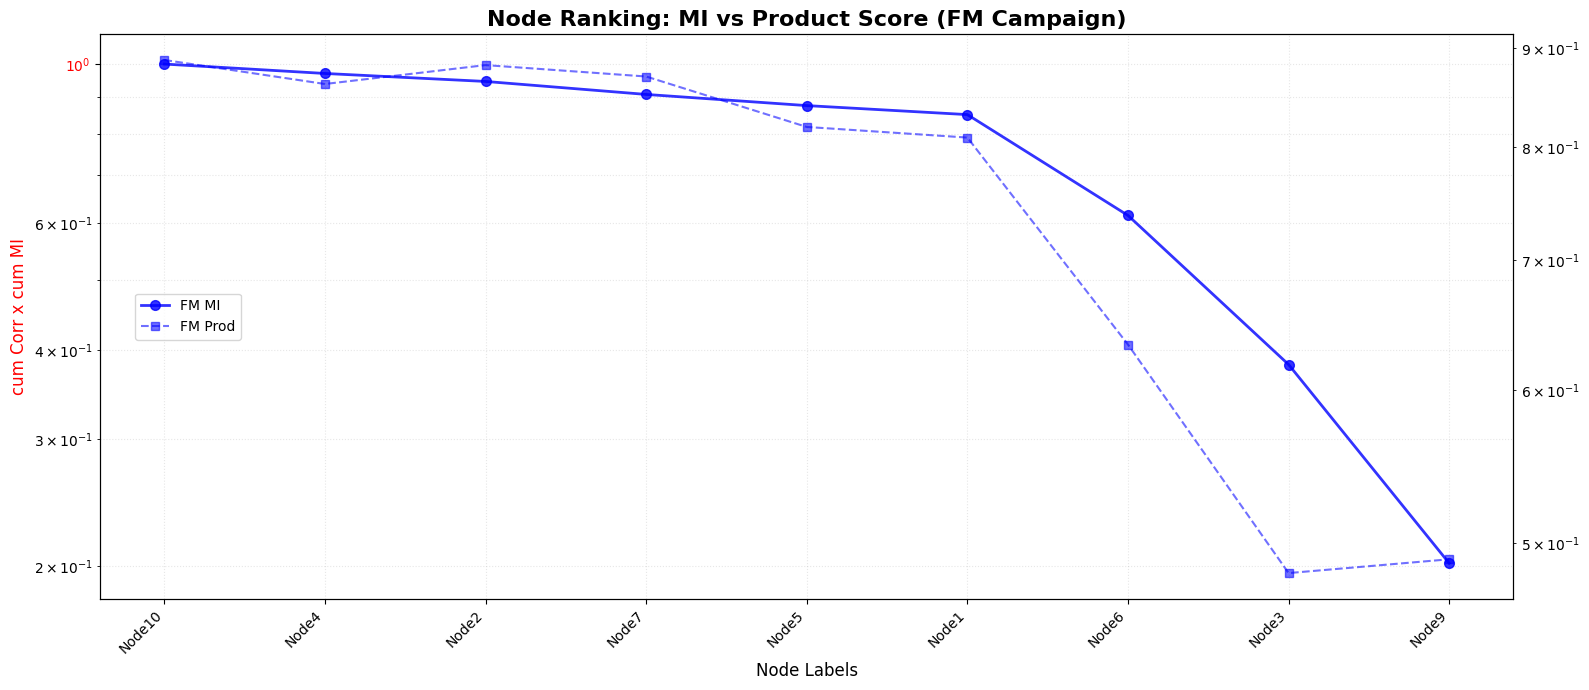

In [8]:
# IMPORTANT: This calculates the MI, Correlation, and sorts the nodes
analyzer.execute(alpha=0.5)

# 2. Setup Figure
fig, ax_mi = plt.subplots(figsize=(16, 7))

# 3. Plot using the helper 
# We use 'b' (blue) and 'r' (red) to match the example style
lines = analyzer.plot_ranking(ax_mi, label="FM")

# --- Styling & Beauty ---
ax_mi.set_title("Node Ranking: MI vs Product Score (FM Campaign)", fontsize=16, fontweight='bold')
ax_mi.set_xlabel("Node Labels", fontsize=12)
ax_mi.set_ylabel("Cumulative MI", color='b', fontsize=12)
ax_mi.tick_params(axis='y', labelcolor='b')

# Retrieve the twin axis for the right side label
ax_prod = ax_mi.get_shared_x_axes().get_siblings(ax_mi)[1]
ax_prod.set_ylabel("cum Corr x cum MI", color='r', fontsize=12)
ax_prod.tick_params(axis='y', labelcolor='r')

# Match the limits from your example
ax_mi.set_ylim(0.18, 1.1)
ax_prod.set_ylim(0.18, 1.1)

# Clean legend handling
labs = [l.get_label() for l in lines]
ax_mi.legend(lines, labs, loc='center left', bbox_to_anchor=(0.02, 0.5), frameon=True)

ax_mi.grid(True, which='both', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()